<a href="https://colab.research.google.com/github/arifurremon/114/blob/main/heart_disease_allinone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1:** Load data, preprocess, train 5 baseline ML models, and evaluate.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)

df = pd.read_csv("heart.csv")
print("Dataset shape:", df.shape)
display(df.head())

print("\nMissing values:\n", df.isnull().sum())

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1-score": round(f1, 3),
        "ROC-AUC": round(auc, 3),
    })

results_df = pd.DataFrame(results)
print("\n===== FINAL COMPARISON TABLE =====")
display(results_df)

results_df.to_csv("model_results.csv", index=False)
print("\nSaved results to model_results.csv")


Dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

===== FINAL COMPARISON TABLE =====


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.803,0.769,0.909,0.833,0.869
1,SVM,0.820,0.775,0.939,0.849,0.883
2,KNN,0.803,0.769,0.909,0.833,0.863
3,Decision Tree,0.787,0.750,0.909,0.822,0.818
4,Random Forest,0.803,0.756,0.939,0.838,0.911



Saved results to model_results.csv


**Step 2:** Comparison chart of all models.

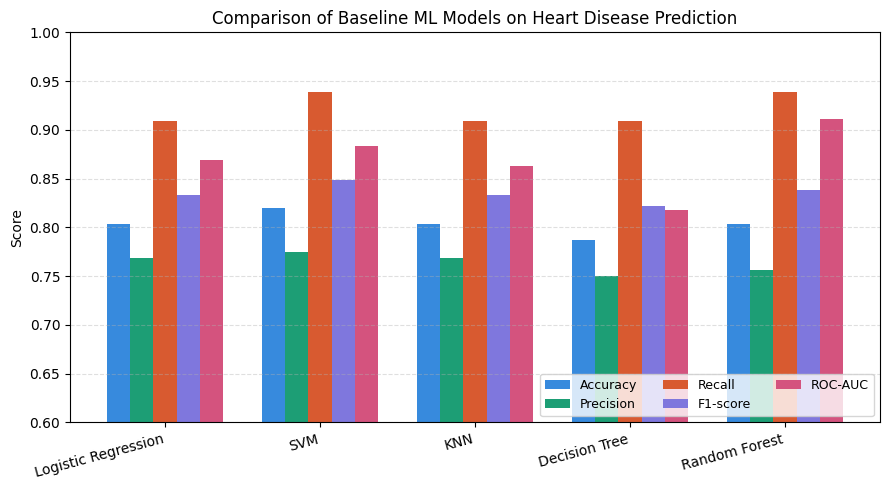

In [3]:
x = np.arange(len(results_df))
width = 0.15
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
colors = ["#378ADD", "#1D9E75", "#D85A30", "#7F77DD", "#D4537E"]

fig, ax = plt.subplots(figsize=(9, 5))
for i, m in enumerate(metrics):
    ax.bar(x + i * width, results_df[m], width, label=m, color=colors[i])

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df["Model"], rotation=15, ha="right")
ax.set_ylim(0.6, 1.0)
ax.set_ylabel("Score")
ax.set_title("Comparison of Baseline ML Models on Heart Disease Prediction")
ax.legend(loc="lower right", ncol=3, fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=200)
plt.show()


**Step 3:** Confusion matrix heatmaps for all 5 models.

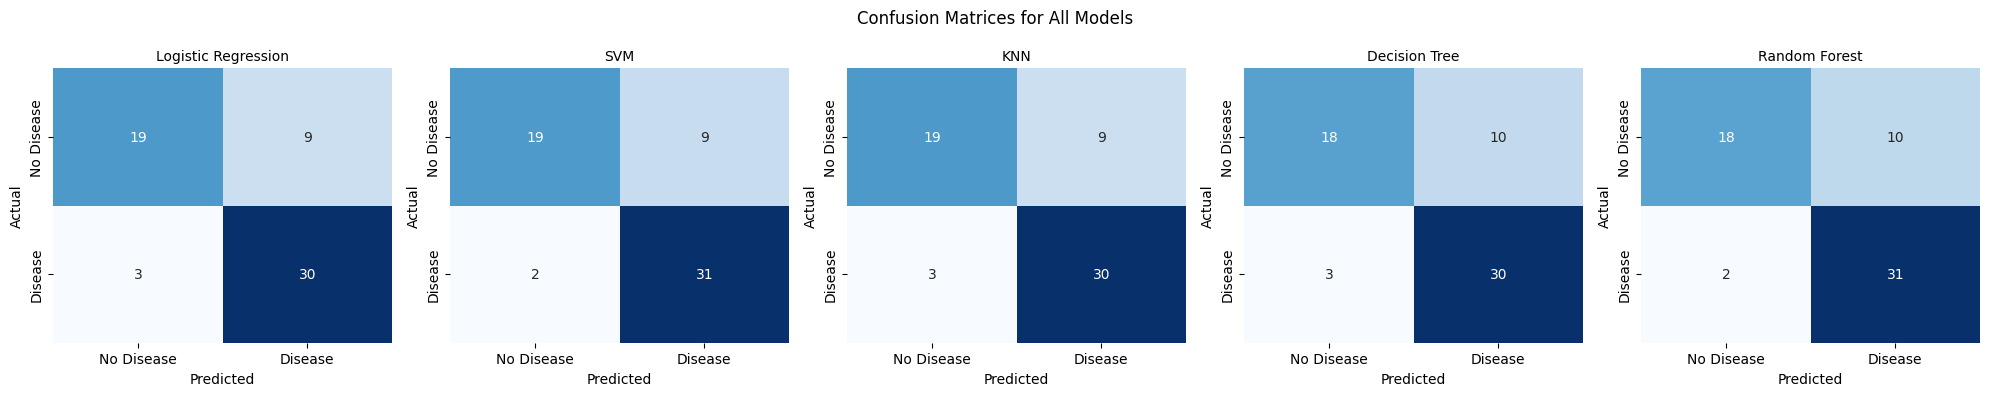

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, name in zip(axes, models.keys()):
    model = models[name]
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["No Disease", "Disease"],
                yticklabels=["No Disease", "Disease"])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices for All Models")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=200)
plt.show()


**Step 4 (optional):** Download result CSV and chart images to your computer.

In [5]:
from google.colab import files
files.download("model_results.csv")
files.download("model_comparison.png")
files.download("confusion_matrices.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>